# Content-Based Filtering
TF-IDF + Cosine Similarity

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from ml.preprocess import load_data, preprocess_movies_and_tags, build_popularity_scores
from ml.content_based import ContentBasedRecommender

In [3]:
ratings, movies, tags, links = load_data(
    ratings_path="../data/ratings.csv",
    movies_path="../data/movies.csv",
    tags_path="../data/tags.csv",
    links_path="../data/links.csv"
)
movie_features = preprocess_movies_and_tags(movies, tags, links, include_title=True)
print("Movie features shape:", movie_features.shape)
movie_features[["movieId", "title", "content_text"]].head()

Movie features shape: (9742, 9)


,movieId,title,content_text
0,1,Toy Story (1995),toy story adventure animation children comedy ...
1,2,Jumanji (1995),jumanji adventure children fantasy fantasy mag...
2,3,Grumpier Old Men (1995),grumpier old men comedy romance moldy old
3,4,Waiting to Exhale (1995),waiting to exhale comedy drama romance
4,5,Father of the Bride Part II (1995),father of the bride part ii comedy pregnancy r...


In [4]:
# Antrenare model content-based (TF-IDF, use_sbert=False pentru viteza)
cb_model = ContentBasedRecommender(max_features=5000, use_sbert=False)
cb_model.fit(movie_features)
print("Model antrenat. Vocabular TF-IDF:", len(cb_model.vectorizer.vocabulary_), "termeni")

Model antrenat. Vocabular TF-IDF: 5000 termeni


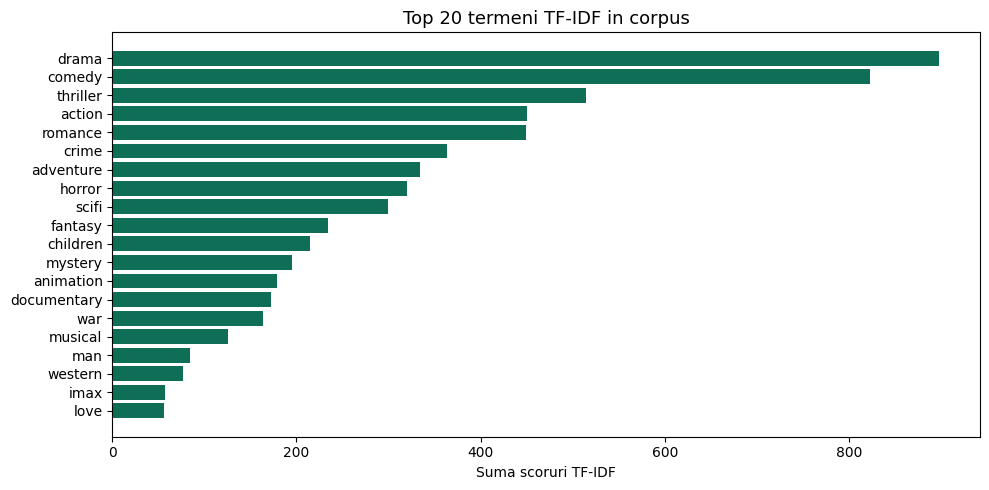

In [5]:
# Top 20 termeni TF-IDF dupa suma scorurilor
tfidf_dense = cb_model.tfidf_matrix.toarray()
feature_names = cb_model.vectorizer.get_feature_names_out()
term_scores = tfidf_dense.sum(axis=0)
top_idx = term_scores.argsort()[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feature_names[top_idx][::-1], term_scores[top_idx][::-1], color="#0F6E56")
ax.set_xlabel("Suma scoruri TF-IDF")
ax.set_title("Top 20 termeni TF-IDF in corpus", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/content_tfidf_termeni.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Recomandari pentru un utilizator
user_id = 1
liked_threshold = 4.0
liked_movies = ratings[(ratings["userId"] == user_id) & (ratings["rating"] >= liked_threshold)]["movieId"].tolist()
liked_titles = movies[movies["movieId"].isin(liked_movies)]["title"].tolist()

print(f"User {user_id} a apreciat {len(liked_titles)} filme, printre care:")
for t in liked_titles[:5]:
    print(" -", t)

# Calculam scoruri content-based prin cosine similarity
liked_indices = [cb_model.movie_id_to_idx[mid] for mid in liked_movies if mid in cb_model.movie_id_to_idx]
rated_ids = set(ratings[ratings["userId"] == user_id]["movieId"].tolist())
candidate_ids = [mid for mid in cb_model.movie_id_to_idx if mid not in rated_ids]
candidate_indices = [cb_model.movie_id_to_idx[mid] for mid in candidate_ids]

input_vecs = cb_model.tfidf_matrix[liked_indices]
cand_vecs  = cb_model.tfidf_matrix[candidate_indices]

sim_matrix    = linear_kernel(cand_vecs, input_vecs)  # (n_cand, n_liked)
content_scores = sim_matrix.mean(axis=1)               # media similaritatilor

top_idx  = np.argsort(content_scores)[::-1][:10]
top10_cb = pd.DataFrame({
    "movieId":       [candidate_ids[i] for i in top_idx],
    "content_score": [float(content_scores[i]) for i in top_idx],
}).merge(movies[["movieId", "title", "genres"]], on="movieId")

print("\nTop 10 recomandari:")
print(top10_cb[["title", "genres", "content_score"]].to_string(index=False))

User 1 a apreciat 200 filme, printre care:
 - Toy Story (1995)
 - Grumpier Old Men (1995)
 - Heat (1995)
 - Seven (a.k.a. Se7en) (1995)
 - Usual Suspects, The (1995)

Top 10 recomandari:
                       title                                     genres  content_score
            Flashback (1990)        Action|Adventure|Comedy|Crime|Drama       0.147055
        Your Highness (2011)            Action|Adventure|Comedy|Fantasy       0.144410
            Condorman (1981)           Action|Adventure|Children|Comedy       0.140787
            Sidekicks (1992)           Action|Adventure|Children|Comedy       0.140787
                 Bolt (2008) Action|Adventure|Animation|Children|Comedy       0.140201
               Merlin (1998)     Action|Adventure|Drama|Fantasy|Romance       0.137343
Dukes of Hazzard, The (2005)                    Action|Adventure|Comedy       0.136619
               Sahara (2005)                    Action|Adventure|Comedy       0.136619
         Rundown, The (2003)  

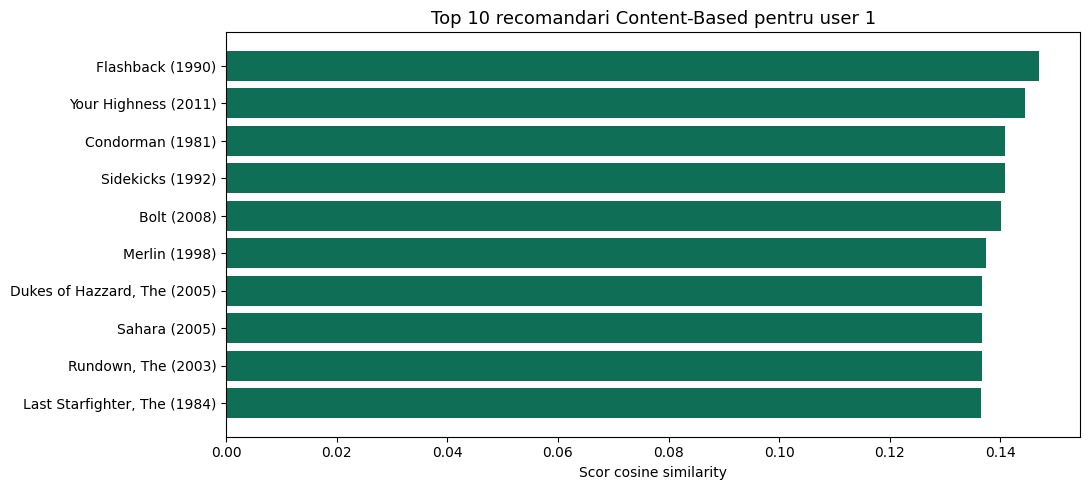

In [7]:
# Grafic top 10 recomandari content-based
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top10_cb["title"][::-1], top10_cb["content_score"][::-1], color="#0F6E56")
ax.set_xlabel("Scor cosine similarity")
ax.set_title(f"Top 10 recomandari Content-Based pentru user {user_id}", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/content_top10.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Similaritate intre doua filme (exemplu)
film_a = "Toy Story (1995)"
film_b = "Toy Story 2 (1999)"

row_a = movie_features[movie_features["title"] == film_a]
row_b = movie_features[movie_features["title"] == film_b]

if not row_a.empty and not row_b.empty:
    idx_a = cb_model.movie_id_to_idx[row_a.iloc[0]["movieId"]]
    idx_b = cb_model.movie_id_to_idx[row_b.iloc[0]["movieId"]]
    vec_a = cb_model.tfidf_matrix[idx_a]
    vec_b = cb_model.tfidf_matrix[idx_b]
    sim = linear_kernel(vec_a, vec_b)[0][0]
    print(f"Similaritate cosinus intre:\n  '{film_a}'\n  '{film_b}'\n  => {sim:.4f}")
else:
    print("Un film nu a fost gasit.")

Similaritate cosinus intre:
  'Toy Story (1995)'
  'Toy Story 2 (1999)'
  => 0.7094


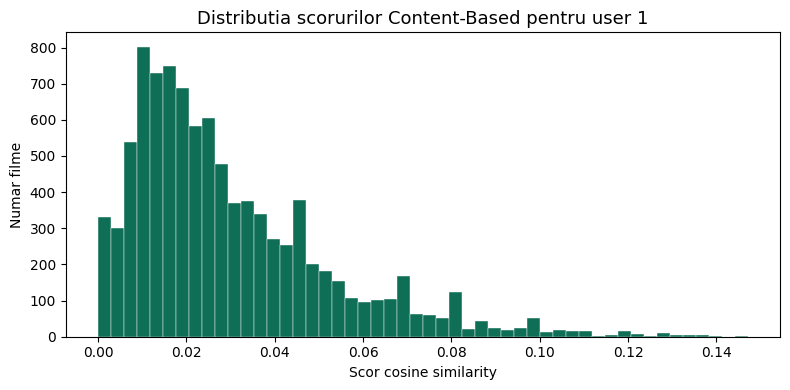

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(content_scores, bins=50, color="#0F6E56", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Scor cosine similarity")
ax.set_ylabel("Numar filme")
ax.set_title(f"Distributia scorurilor Content-Based pentru user {user_id}", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/content_distributie_scoruri.png", dpi=150, bbox_inches="tight")
plt.show()